<a href="https://colab.research.google.com/github/Ranger3560/Stock-Market/blob/main/Stock_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load efficiently
df = pd.read_csv("/content/sample_data/indian_stocks_all_history.csv", parse_dates=["date"])

# Optimize memory
df["ticker"] = df["ticker"].astype("category")
df["exchange"] = df["exchange"].astype("category")

# Sort for time series operations
df = df.sort_values(["ticker", "date"])

# Basic sanity check
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 4525750 entries, 12295 to 4513005
Data columns (total 8 columns):
 #   Column    Dtype         
---  ------    -----         
 0   ticker    category      
 1   exchange  category      
 2   date      datetime64[ns]
 3   open      float64       
 4   high      float64       
 5   low       float64       
 6   close     float64       
 7   volume    int64         
dtypes: category(2), datetime64[ns](1), float64(4), int64(1)
memory usage: 254.7 MB
None
          ticker exchange       date   open   high    low  close  volume
12295  20MICRONS      NSE 2021-04-28  36.87  37.46  36.53  36.97   56095
13532  20MICRONS      BSE 2021-04-28  36.72  37.57  36.13  37.17    8937
12296  20MICRONS      NSE 2021-04-29  37.36  38.39  36.13  38.05  128921
13533  20MICRONS      BSE 2021-04-29  37.91  41.08  36.63  38.95   10983
12297  20MICRONS      NSE 2021-04-30  38.35  39.82  37.41  37.56  286685


In [ ]:
df["return"] = df.groupby("ticker")["close"].pct_change()

/tmp/ipykernel_1793/2179457098.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["return"] = df.groupby("ticker")["close"].pct_change()


In [ ]:
df["ma_10"] = df.groupby("ticker")["close"].transform(lambda x: x.rolling(10).mean())
df["ma_50"] = df.groupby("ticker")["close"].transform(lambda x: x.rolling(50).mean())

/tmp/ipykernel_1793/4258536707.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["ma_10"] = df.groupby("ticker")["close"].transform(lambda x: x.rolling(10).mean())
/tmp/ipykernel_1793/4258536707.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["ma_50"] = df.groupby("ticker")["close"].transform(lambda x: x.rolling(50).mean())


In [ ]:
df["volatility"] = df.groupby("ticker")["return"].transform(lambda x: x.rolling(10).std())

/tmp/ipykernel_1793/1248511614.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["volatility"] = df.groupby("ticker")["return"].transform(lambda x: x.rolling(10).std())


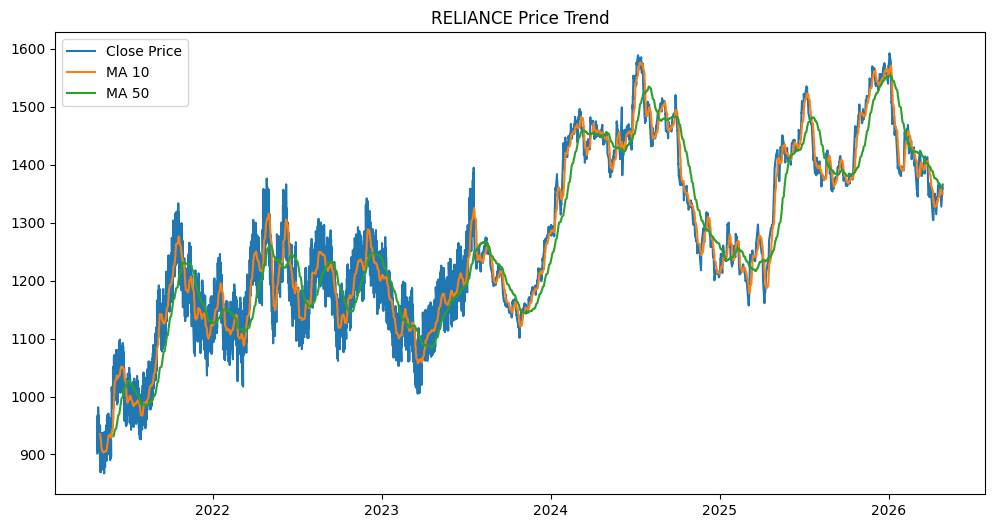

In [ ]:
import matplotlib.pyplot as plt

stock = df[df["ticker"] == "RELIANCE"]

plt.figure(figsize=(12,6))
plt.plot(stock["date"], stock["close"], label="Close Price")
plt.plot(stock["date"], stock["ma_10"], label="MA 10")
plt.plot(stock["date"], stock["ma_50"], label="MA 50")

plt.title("RELIANCE Price Trend")
plt.legend()
plt.show()

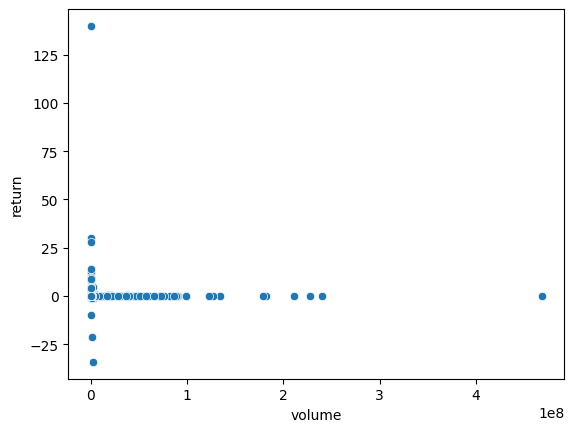

In [ ]:
import seaborn as sns

# Sample for performance
sample_df = df.sample(10000)

sns.scatterplot(data=sample_df, x="volume", y="return")
plt.show()

In [ ]:
# Lag features
df["lag_1"] = df.groupby("ticker")["close"].shift(1)
df["lag_2"] = df.groupby("ticker")["close"].shift(2)

# Price change
df["price_change"] = df["close"] - df["open"]

# Drop NA after lagging
df = df.dropna()

/tmp/ipykernel_1793/207341459.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["lag_1"] = df.groupby("ticker")["close"].shift(1)
/tmp/ipykernel_1793/207341459.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["lag_2"] = df.groupby("ticker")["close"].shift(2)


In [ ]:
df_rel = df[df["ticker"] == "RELIANCE"].copy()

In [ ]:
df_sample = df_rel.tail(50000)  # recent data is more useful

In [ ]:
pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.235749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 3528170, number of used features: 6
[LightGBM] [Info] Start training from score 796.877318


In [ ]:
df["target"] = df["close"].pct_change().shift(-1)
df = df.dropna()

In [ ]:
df["direction"] = (df["close"].shift(-1) > df["close"]).astype(int)

In [ ]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.215191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 3528170, number of used features: 6
[LightGBM] [Info] Start training from score 796.877318


In [ ]:
# RSI (simple version)
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["rsi"] = 100 - (100 / (1 + rs))

In [ ]:
df["momentum_5"] = df["close"] - df["close"].shift(5)
df["momentum_10"] = df["close"] - df["close"].shift(10)

In [ ]:
# Define features (X) and target (y) from the processed DataFrame
# This ensures X and y have consistent lengths after all NaN removals

# List of all potential features created so far
all_features = [
    'open', 'high', 'low', 'volume', 'lag_1', 'lag_2',
    'ma_10', 'ma_50', 'volatility', 'price_change',
    'rsi', 'momentum_5', 'momentum_10'
]

# Filter to include only columns present in the current df
existing_features = [col for col in all_features if col in df.columns]

X = df[existing_features]
y = df['target']

# Concatenate X and y and drop rows with any NaN values to ensure perfect alignment
combined_df = pd.concat([X, y], axis=1).dropna()
X = combined_df[existing_features]
y = combined_df['target']

print(f"New X shape: {X.shape}")
print(f"New y shape: {y.shape}")

New X shape: (4401599, 13)
New y shape: (4401599,)


In [ ]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [ ]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.146179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 3528169, number of used features: 13
[LightGBM] [Info] Start training from score 0.052673


In [ ]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [ ]:
import numpy as np

strategy_returns = df["return"].iloc[split:] * preds
print("Strategy Return:", np.sum(strategy_returns))

Strategy Return: 2302434.587333577


In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    n_jobs=-1
)

In [ ]:
df_test = df.iloc[split:].copy()
df_test["predicted_close"] = preds

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


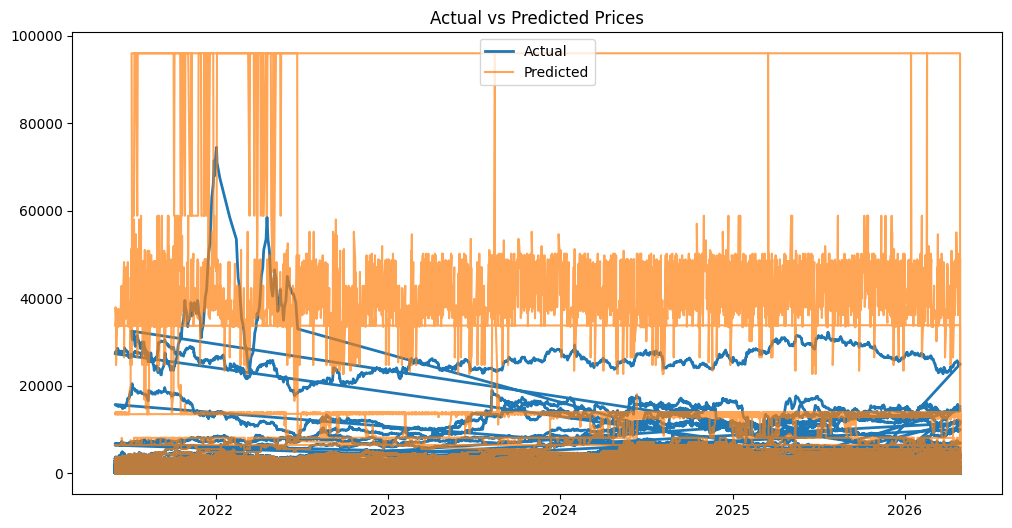

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_test["date"], df_test["close"], label="Actual", linewidth=2)
plt.plot(df_test["date"], df_test["predicted_close"], label="Predicted", alpha=0.7)

plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [ ]:
print(df_test[["date", "close", "predicted_close"]].head(10))

              date   close  predicted_close
4082638 2022-03-15  219.29       228.847325
2206575 2022-03-16  227.36       228.847325
4082639 2022-03-16  227.93       228.847325
2206576 2022-03-17  221.97       228.847325
4082640 2022-03-17  223.73       225.711611
2206577 2022-03-21  218.67       225.711611
4082641 2022-03-21  218.55       222.048837
2206578 2022-03-22  216.29       219.364881
4082642 2022-03-22  217.11       217.428817
2206579 2022-03-23  214.22       219.364881


In [ ]:
df_test["predicted_direction"] = preds
df_test["actual_direction"] = y_test

In [ ]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, preds))

R2 Score: -0.06855500820646987
